In [2]:
library(Seurat)
library(Signac)
library(EnsDb.Hsapiens.v86)
library(BSgenome.Hsapiens.UCSC.hg38)
library(S4Vectors)
library(ggplot2)
library(patchwork)
library(GenomicRanges)

library(BiocParallel)
library(chromVAR)
library(JASPAR2020)
library(TFBSTools)
library(motifmatchr)
library(SeuratWrappers)
library(monocle3)
library(Matrix)
library(cicero)
library(stringr)

set.seed(777)

#Set working directory
setwd("/storage1/fs1/jmillman/Active/DigitalTwin")
#setwd("/storage1/fs1/jmillman/Active/Ed/Catalyst_paper")

In [3]:
# Load Data

combined.data<-readRDS("checkpoints/MultiomeAtlas_integratedFULLpt_annotated.rds"))

combined.data

An object of class Seurat 
1180763 features across 69535 samples within 4 assays 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 3 other assays present: ATAC, peaks, integrated.peaks
 11 dimensional reductions calculated: pca, umap.rna.merged, integrated.cca, umap.integrated.cca, integrated.rpca, umap.integrated.rpca, harmony, umap.harmony, integrated.lsi, umap.integrated.joint, lsi

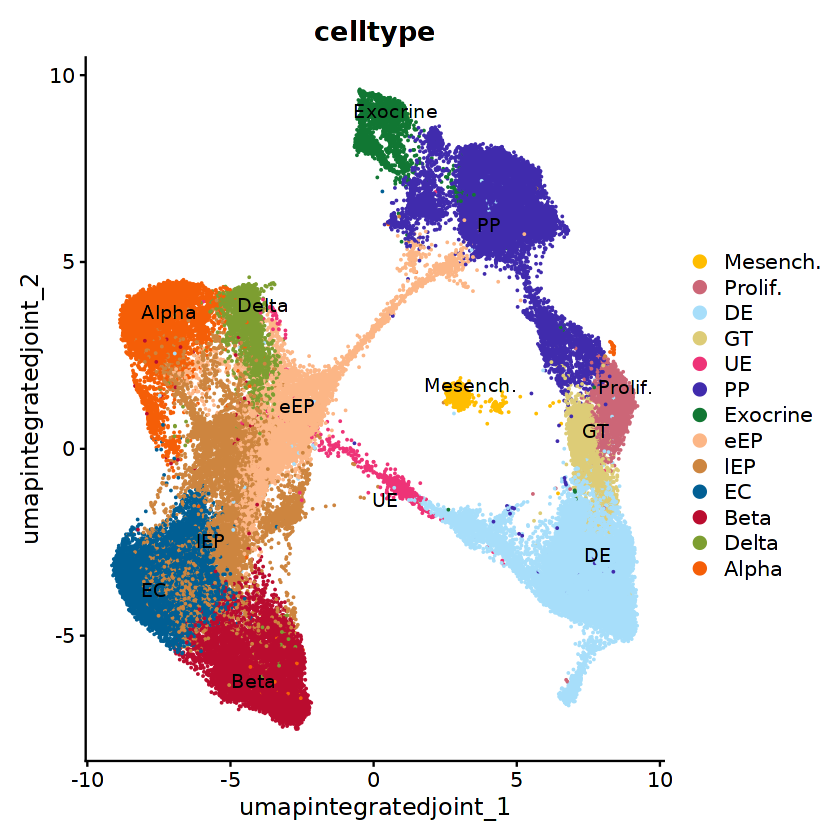

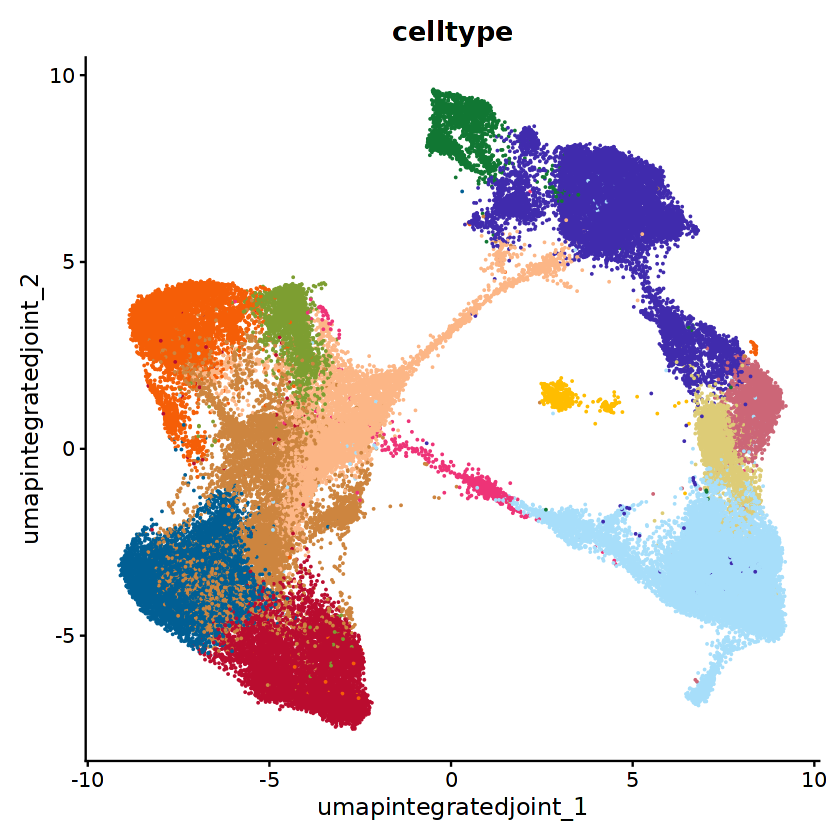

In [10]:
#Color to plot
pal <- c(
  "Mesench." = "#ffbd00",  # yellow
  "Prolif."  = "#CC6677", # dusty rose / muted red
  "DE"       = "#a7defa", # light sky blue
  "GT"       = "#DDCC77", # warm sand / golden khaki
  "PP"       = "#402bad", # deep indigo
  "Exocrine" = "#117733", # forest green
  "UE"       = "#EE3377", # magenta / raspberry
  "lEP"      = '#cd853f', #Peru color
  "eEP"      = "#fcb686", # light orange
  "SIC"       = "#015f94", # royal blue
  #"eSIC"      = "#16baf7", # sky blue
  #"Beta-SIC"     = "#AA4499", # plum / purple-rose
  #"eBeta"       = "#f77785", # light red
  "Beta"        = "#ba0c2f", # WashU red
  "Delta"        = "#7d9e31", # olive
  "Alpha"        = "#f55e07" # vivid orange
)

DimPlot(combined.data, label = TRUE, repel = TRUE, 
        reduction = "umap.integrated.joint",group.by = 'celltype', cols=pal) 

DimPlot(combined.data,  repel = TRUE, 
        reduction = "umap.integrated.joint",group.by = 'celltype', cols=pal) + theme(legend.position = "none")

In [11]:
# save metadata table:
combined.data$barcode <- colnames(combined.data)
combined.data$UMAP_1 <- combined.data@reductions$umap.integrated.joint@cell.embeddings[,1]
combined.data$UMAP_2 <- combined.data@reductions$umap.integrated.joint@cell.embeddings[,2]
write.csv(combined.data@meta.data, file='checkpoints/MultiVelo/seurat_wnn/metadata.csv', quote=F, row.names=F)

In [12]:
#Export data for Multivelo
combined.data[["barcode"]] <- colnames(combined.data)
df.barcode <- data.frame(first_column=colnames(combined.data),second_column=combined.data@meta.data$barcode)
write.table(df.barcode, "checkpoints/MultiVelo/seurat_wnn/combined_barcodes.csv", sep = ',', row.names = F, col.names = F, quote = F)

df.dataset <- data.frame(first_column=colnames(combined.data),second_column=combined.data@meta.data$dataset)
write.table(df.dataset, "checkpoints/MultiVelo/seurat_wnn/combined_dataset.csv", sep = ',', row.names = F, col.names = F, quote = F)

# extract neighborhood graph
nn_idx <- combined.data@neighbors$weighted.nn@nn.idx
nn_dist <- combined.data@neighbors$weighted.nn@nn.dist
nn_cells <- combined.data@neighbors$weighted.nn@cell.names

# save neighborhood graph
write.table(nn_idx, "checkpoints/MultiVelo/seurat_wnn/combined_nn_idx.txt", sep = ',', row.names = F, col.names = F, quote = F)
write.table(nn_dist, "checkpoints/MultiVelo/seurat_wnn/combined_nn_dist.txt", sep = ',', row.names = F, col.names = F, quote = F)
write.table(nn_cells, "checkpoints/MultiVelo/seurat_wnn/combined_nn_cells.txt", sep = ',', row.names = F, col.names = F, quote = F)

In [13]:
# write dimensional reduction matrix (PCA)
write.csv (combined.data@reductions$pca@cell.embeddings, 
           file='checkpoints/MultiVelo/seurat_wnn/pca.csv', quote=F, row.names=F)


In [ ]:
#And I pray, oh, my God, do I pray? I pray every single day for a revolution - What's Up? by 4 Non Blondes